<a href="https://colab.research.google.com/github/Rawan806/2025_GP_18/blob/main/Wadiah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wadiah Offline Embedding & Indexing Pipeline

This notebook builds a reproducible offline embedding index for Wadiah items
to be used later by the FastAPI similarity retrieval service.

Pipeline steps:
1. Load unified CSV data
2. Validate and clean records
3. Separate indexable vs non-indexable items
4. Download images with retry/backoff
5. Apply canonical preprocessing
6. Extract embeddings using MobileNetV3Small
7. Build aligned embeddings + metadata index
8. Export artifacts for API usage

In [1]:
import os
import io
import json
import time
import uuid
import hashlib
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datetime import datetime, UTC
from typing import List, Dict, Tuple, Optional

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

#### this cell is for a clear constant between Colab and the API:

In [2]:
# ========= Paths =========
DATA_PATH = "wadiah_items_clean.csv"
CACHE_DIR = "image_cache"
ARTIFACT_DIR = "artifacts"

# ========= Image / Model Config =========
IMG_SIZE = 224
MODEL_NAME = "MobileNetV3Small"
PREPROCESS_NAME = "mobilenet_v3.preprocess_input"
RESIZE_METHOD = "direct_resize"
POOLING = "avg"

# ========= Download Config =========
REQUEST_TIMEOUT = 15
MAX_RETRIES = 3
BACKOFF_BASE = 1.5
SAVE_IMAGE_CACHE = True

# ========= Retrieval Config =========
TOP_K = 5
STRONG_MATCH_THRESHOLD = 0.85
POTENTIAL_MATCH_THRESHOLD = 0.75

# ========= Misc =========
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(ARTIFACT_DIR, exist_ok=True)

In [3]:
PREPROCESS_CONFIG = {
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "resize_method": RESIZE_METHOD,
    "preprocess_name": PREPROCESS_NAME,
    "pooling": POOLING,
    "l2_normalization": True
}

PREPROCESS_CONFIG

{'model_name': 'MobileNetV3Small',
 'img_size': 224,
 'resize_method': 'direct_resize',
 'preprocess_name': 'mobilenet_v3.preprocess_input',
 'pooling': 'avg',
 'l2_normalization': True}

In [4]:
import pandas as pd

df = pd.read_csv(DATA_PATH)
print("Original shape:", df.shape)
df.head()

Original shape: (588, 9)


,docId,collection,createdAt,eventAt,location,status,type,color,imageUrl
0,0HEC5CVy98i1XyR9nkEt,lost,2025-12-01 10:00:00,2025-12-01 9:30:00,المسعى,قيد المراجعة,حقيبة يد,سماوي,https://firebasestorage.googleapis.com/v0/b/wa...
1,0f8TYE8Y5A4UPETYXggB,lost,2025-12-02 11:00:00,2025-12-02 10:40:00,المطاف,جاهز للاستلام,ساعة,أزرق,https://firebasestorage.googleapis.com/v0/b/wa...
2,0ol9hH8T9DbZtAHOlkOW,lost,2025-12-03 12:00:00,2025-12-03 11:50:00,السطح,جاهز للاستلام,ساعة,سماوي,https://firebasestorage.googleapis.com/v0/b/wa...
3,0vKY3aacryPAQFrxjqmI,lost,2025-12-03 13:00:00,2025-12-03 12:45:00,المسعى,مغلقة,حقيبة ظهر,أحمر,https://firebasestorage.googleapis.com/v0/b/wa...
4,1PH8TOp6iVkzgIAkqitS,lost,2025-12-04 14:00:00,2025-12-04 13:50:00,الساحة الشرقية,قيد المراجعة,جوال,أحمر,https://firebasestorage.googleapis.com/v0/b/wa...


#### Normalize Column Names:

In [5]:
df.columns = [str(c).strip() for c in df.columns]
print(df.columns.tolist())

['docId', 'collection', 'createdAt', 'eventAt', 'location', 'status', 'type', 'color', 'imageUrl']


In [6]:
required_cols = ["docId", "imageUrl", "collection"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Schema validation passed ")

Schema validation passed 


#### Standardize Core Fields:

In [7]:
df["docId"] = df["docId"].astype(str).str.strip()
df["imageUrl"] = df["imageUrl"].astype(str).str.strip()
df["collection"] = df["collection"].astype(str).str.strip().str.lower()

# توحيد collection
df["collection"] = df["collection"].replace({
    "lostitems": "lost",
    "lostitem": "lost",
    "lost_items": "lost",
    "lost": "lost",
    "founditems": "found",
    "founditem": "found",
    "found_items": "found",
    "found": "found"
})

optional_cols = ["createdAt", "status", "type", "color", "aiTypes", "aiColor", "eventAt", "location"]
for col in optional_cols:
    if col not in df.columns:
        df[col] = None

df.head()

,docId,collection,createdAt,eventAt,location,status,type,color,imageUrl,aiTypes,aiColor
0,0HEC5CVy98i1XyR9nkEt,lost,2025-12-01 10:00:00,2025-12-01 9:30:00,المسعى,قيد المراجعة,حقيبة يد,سماوي,https://firebasestorage.googleapis.com/v0/b/wa...,None,None
1,0f8TYE8Y5A4UPETYXggB,lost,2025-12-02 11:00:00,2025-12-02 10:40:00,المطاف,جاهز للاستلام,ساعة,أزرق,https://firebasestorage.googleapis.com/v0/b/wa...,None,None
2,0ol9hH8T9DbZtAHOlkOW,lost,2025-12-03 12:00:00,2025-12-03 11:50:00,السطح,جاهز للاستلام,ساعة,سماوي,https://firebasestorage.googleapis.com/v0/b/wa...,None,None
3,0vKY3aacryPAQFrxjqmI,lost,2025-12-03 13:00:00,2025-12-03 12:45:00,المسعى,مغلقة,حقيبة ظهر,أحمر,https://firebasestorage.googleapis.com/v0/b/wa...,None,None
4,1PH8TOp6iVkzgIAkqitS,lost,2025-12-04 14:00:00,2025-12-04 13:50:00,الساحة الشرقية,قيد المراجعة,جوال,أحمر,https://firebasestorage.googleapis.com/v0/b/wa...,None,None


#### Define ready index criteria:

In [8]:
def is_valid_http_url(url: str) -> bool:
    if not isinstance(url, str):
        return False
    url = url.strip().lower()
    return url.startswith("http://") or url.startswith("https://")

def evaluate_index_readiness(row: pd.Series) -> Tuple[bool, List[str]]:
    reasons = []

    doc_id = str(row.get("docId", "")).strip()
    image_url = str(row.get("imageUrl", "")).strip()
    collection = str(row.get("collection", "")).strip().lower()

    if doc_id == "" or doc_id.lower() == "nan":
        reasons.append("missing_docId")

    if image_url == "" or image_url.lower() == "nan":
        reasons.append("missing_imageUrl")
    elif not is_valid_http_url(image_url):
        reasons.append("invalid_imageUrl")

    if collection not in {"lost", "found"}:
        reasons.append("invalid_collection")

    return len(reasons) == 0, reasons

#### Separate Indexable vs Non-Indexable:

In [9]:
indexable_rows = []
non_indexable_items = []

for _, row in df.iterrows():
    ok, reasons = evaluate_index_readiness(row)

    row_dict = row.to_dict()

    if ok:
        indexable_rows.append(row_dict)
    else:
        row_dict["non_indexable_reasons"] = reasons
        non_indexable_items.append(row_dict)

indexable_df = pd.DataFrame(indexable_rows)

print("Indexable rows before dedup:", len(indexable_df))
print("Non-indexable rows:", len(non_indexable_items))

Indexable rows before dedup: 588
Non-indexable rows: 0


#### Deduplicate Records:

In [10]:
duplicate_doc_mask = indexable_df.duplicated(subset=["docId"], keep="first")
duplicate_img_mask = indexable_df.duplicated(subset=["imageUrl"], keep="first")
duplicate_mask = duplicate_doc_mask | duplicate_img_mask

duplicates_df = indexable_df[duplicate_mask].copy()
clean_df = indexable_df[~duplicate_mask].copy().reset_index(drop=True)

for _, row in duplicates_df.iterrows():
    row_dict = row.to_dict()
    reasons = []
    if row["docId"] in indexable_df.loc[duplicate_doc_mask, "docId"].values:
        reasons.append("duplicate_docId")
    if row["imageUrl"] in indexable_df.loc[duplicate_img_mask, "imageUrl"].values:
        reasons.append("duplicate_imageUrl")
    row_dict["non_indexable_reasons"] = reasons if reasons else ["duplicate_record"]
    non_indexable_items.append(row_dict)

print("Clean rows after dedup:", len(clean_df))
print("Total non-indexable rows now:", len(non_indexable_items))

Clean rows after dedup: 588
Total non-indexable rows now: 0


#### Quick Cleaning

In [11]:
cleaning_report = {
    "raw_rows": int(len(df)),
    "indexable_before_dedup": int(len(indexable_df)),
    "clean_rows_after_dedup": int(len(clean_df)),
    "non_indexable_count": int(len(non_indexable_items))
}

cleaning_report

{'raw_rows': 588,
 'indexable_before_dedup': 588,
 'clean_rows_after_dedup': 588,
 'non_indexable_count': 0}

#### Build Feature Extractor

In [12]:
base_model = MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling=POOLING
)

print("Feature extractor ready ")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Feature extractor ready 


#### Download Helper with Retry/Backoff

In [13]:
def make_cache_filename(doc_id: str, image_url: str) -> str:
    key = f"{doc_id}__{image_url}"
    h = hashlib.md5(key.encode("utf-8")).hexdigest()
    return os.path.join(CACHE_DIR, f"{h}.jpg")

def download_image(url: str, doc_id: str, timeout: int = REQUEST_TIMEOUT,
                   retries: int = MAX_RETRIES, backoff_base: float = BACKOFF_BASE,
                   save_cache: bool = SAVE_IMAGE_CACHE) -> Image.Image:
    cache_path = make_cache_filename(doc_id, url)

    if save_cache and os.path.exists(cache_path):
        return Image.open(cache_path).convert("RGB")

    last_error = None

    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=timeout)
            response.raise_for_status()

            img = Image.open(io.BytesIO(response.content)).convert("RGB")

            if save_cache:
                img.save(cache_path)

            return img

        except Exception as e:
            last_error = e
            sleep_time = backoff_base ** attempt
            time.sleep(sleep_time)

    raise last_error

#### Canonical Preprocessing Functions

In [14]:
def preprocess_pil_image(img: Image.Image) -> np.ndarray:
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)
    return arr

def extract_embedding(img: Image.Image) -> np.ndarray:
    x = preprocess_pil_image(img)
    x = np.expand_dims(x, axis=0)   # (1, H, W, 3)

    emb = base_model.predict(x, verbose=0)[0]
    emb = emb.astype("float32")

    # L2 normalization
    emb = emb / (np.linalg.norm(emb) + 1e-10)
    return emb

#### Download Images Batch + Build Valid Items

In [15]:
valid_items = []
failed_downloads = []

download_start = time.time()

for _, row in clean_df.iterrows():
    try:
        img = download_image(
            url=row["imageUrl"],
            doc_id=row["docId"]
        )

        valid_items.append({
            "docId": row["docId"],
            "collection": row["collection"],
            "imageUrl": row["imageUrl"],
            "createdAt": row.get("createdAt"),
            "status": row.get("status"),
            "type": row.get("type"),
            "color": row.get("color"),
            "aiTypes": row.get("aiTypes"),
            "aiColor": row.get("aiColor"),
            "eventAt": row.get("eventAt"),
            "location": row.get("location"),
            "img": img
        })

    except Exception as e:
        failed_downloads.append({
            "docId": row["docId"],
            "collection": row["collection"],
            "imageUrl": row["imageUrl"],
            "error": str(e)
        })

download_elapsed = time.time() - download_start

print("Valid downloaded items:", len(valid_items))
print("Failed downloads:", len(failed_downloads))
print("Download time (sec):", round(download_elapsed, 2))

Valid downloaded items: 588
Failed downloads: 0
Download time (sec): 656.33


#### Move Failed Downloads to Non-Indexable

In [16]:
failed_doc_ids = {item["docId"] for item in failed_downloads}

for item in failed_downloads:
    non_indexable_items.append({
        "docId": item["docId"],
        "collection": item["collection"],
        "imageUrl": item["imageUrl"],
        "non_indexable_reasons": ["download_failed"],
        "download_error": item["error"]
    })

print("Updated non-indexable count:", len(non_indexable_items))

Updated non-indexable count: 0


#### Download Report

In [17]:
failure_reason_counts = {}
for item in failed_downloads:
    err = item["error"]
    failure_reason_counts[err] = failure_reason_counts.get(err, 0) + 1

download_report = {
    "total_candidate_images": int(len(clean_df)),
    "successful_downloads": int(len(valid_items)),
    "failed_downloads": int(len(failed_downloads)),
    "download_time_sec": float(round(download_elapsed, 4)),
    "failure_reason_counts": failure_reason_counts
}

download_report

{'total_candidate_images': 588,
 'successful_downloads': 588,
 'failed_downloads': 0,
 'download_time_sec': 656.3348,
 'failure_reason_counts': {}}

#### Preview Failed Downloads

In [18]:
failed_downloads[:5]

[]

## Extract Embeddings + Build Meta!!

In [19]:
embeddings = []
meta = []

embedding_start = time.time()

for item in valid_items:
    emb = extract_embedding(item["img"])
    embeddings.append(emb)

    meta.append({
        "docId": item["docId"],
        "collection": item["collection"],
        "imageUrl": item["imageUrl"],
        "createdAt": item["createdAt"],
        "status": item["status"],
        "type": item["type"],
        "color": item["color"],
        "aiTypes": item["aiTypes"],
        "aiColor": item["aiColor"],
        "eventAt": item["eventAt"],
        "location": item["location"]
    })

embedding_elapsed = time.time() - embedding_start

embeddings = np.stack(embeddings, axis=0) if embeddings else np.empty((0, 0), dtype=np.float32)

print("Embeddings shape:", embeddings.shape)
print("Embedding time (sec):", round(embedding_elapsed, 2))

Embeddings shape: (588, 576)
Embedding time (sec): 59.41


#### Runtime Metrics

In [20]:
num_embedded = len(valid_items)
avg_embedding_time = embedding_elapsed / num_embedded if num_embedded > 0 else None

runtime_metrics = {
    "download_time_sec": float(round(download_elapsed, 4)),
    "embedding_time_sec": float(round(embedding_elapsed, 4)),
    "num_images_embedded": int(num_embedded),
    "avg_embedding_time_per_image_sec": None if avg_embedding_time is None else float(round(avg_embedding_time, 6))
}

runtime_metrics

{'download_time_sec': 656.3348,
 'embedding_time_sec': 59.406,
 'num_images_embedded': 588,
 'avg_embedding_time_per_image_sec': 0.101031}

#### Index Versioning / Metadata

In [21]:
index_id = str(uuid.uuid4())
index_version = datetime.now(UTC).strftime("%Y%m%d_%H%M%S")

dataset_hash = hashlib.md5(
    pd.util.hash_pandas_object(clean_df[["docId", "imageUrl", "collection"]], index=False).values.tobytes()
).hexdigest()

#### Index Info

In [22]:
embedding_dim = int(embeddings.shape[1]) if embeddings.size > 0 else 0

index_info = {
    "index_id": index_id,
    "index_version": index_version,
    "built_at": datetime.now(UTC).isoformat(),
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "preprocessing": PREPROCESS_NAME,
    "resize_method": RESIZE_METHOD,
    "pooling": POOLING,
    "l2_normalization": True,
    "num_items": int(len(meta)),
    "embedding_dim": embedding_dim,
    "similarity_metric": "cosine",
    "dataset_hash": dataset_hash,
    "thresholds": {
        "strong_match_threshold": STRONG_MATCH_THRESHOLD,
        "potential_match_threshold": POTENTIAL_MATCH_THRESHOLD
    },
    "collection_counts": {
        "lost": int(sum(1 for m in meta if m["collection"] == "lost")),
        "found": int(sum(1 for m in meta if m["collection"] == "found"))
    },
    "index_ordering_note": "embeddings rows are aligned with meta entries by identical append order"
}

index_info

{'index_id': '5dbb2025-5917-4c5a-b7e2-015e24d79577',
 'index_version': '20260405_065345',
 'built_at': '2026-04-05T06:53:48.308317+00:00',
 'model_name': 'MobileNetV3Small',
 'img_size': 224,
 'preprocessing': 'mobilenet_v3.preprocess_input',
 'resize_method': 'direct_resize',
 'pooling': 'avg',
 'l2_normalization': True,
 'num_items': 588,
 'embedding_dim': 576,
 'similarity_metric': 'cosine',
 'dataset_hash': 'd17a93ad0e984dabafca2483087be837',
 'thresholds': {'strong_match_threshold': 0.85,
  'potential_match_threshold': 0.75},
 'collection_counts': {'lost': 236, 'found': 352},
 'index_ordering_note': 'embeddings rows are aligned with meta entries by identical append order'}

#### Similarity Helpers

In [23]:
def cosine_similarity_matrix(query_vec: np.ndarray, emb_matrix: np.ndarray) -> np.ndarray:
    return emb_matrix @ query_vec

def get_query_by_doc_id(doc_id: str, meta: List[Dict], embeddings: np.ndarray):
    for i, m in enumerate(meta):
        if str(m["docId"]) == str(doc_id):
            return m, embeddings[i]
    return None, None

def search_top_k(
    query_embedding: np.ndarray,
    query_collection: str,
    embeddings: np.ndarray,
    meta: List[Dict],
    k: int = TOP_K,
    exclude_doc_id: Optional[str] = None
) -> List[Dict]:

    target_collection = "found" if query_collection == "lost" else "lost"

    candidate_indices = [
        i for i, m in enumerate(meta)
        if m["collection"] == target_collection and m["docId"] != exclude_doc_id
    ]

    if not candidate_indices:
        return []

    candidate_embeddings = embeddings[candidate_indices]
    scores = cosine_similarity_matrix(query_embedding, candidate_embeddings)

    top_indices_local = np.argsort(-scores)[:k]

    results = []
    for local_idx in top_indices_local:
        original_idx = candidate_indices[local_idx]
        result = meta[original_idx].copy()
        sim = float(scores[local_idx])

        if sim >= STRONG_MATCH_THRESHOLD:
            match_label = "strong_match"
        elif sim >= POTENTIAL_MATCH_THRESHOLD:
            match_label = "potential_match"
        else:
            match_label = "weak_match"

        result["similarity"] = sim
        result["match_label"] = match_label
        results.append(result)

    return results

#### Quick Retrieval Test

In [24]:
if len(meta) > 0:
    query_doc_id = meta[0]["docId"]
    query_meta, query_emb = get_query_by_doc_id(query_doc_id, meta, embeddings)

    print("Query:")
    print(query_meta)

    results = search_top_k(
        query_embedding=query_emb,
        query_collection=query_meta["collection"],
        embeddings=embeddings,
        meta=meta,
        k=TOP_K,
        exclude_doc_id=query_doc_id
    )

    print("\nTop-K Results:")
    for r in results:
        print(
            r["docId"],
            r["collection"],
            round(r["similarity"], 4),
            r["match_label"],
            r.get("type"),
            r.get("color")
        )
else:
    print("No indexed items available.")

Query:
{'docId': '0HEC5CVy98i1XyR9nkEt', 'collection': 'lost', 'imageUrl': 'https://firebasestorage.googleapis.com/v0/b/wadiah-6225a.firebasestorage.app/o/lost_items%2F1773094711565.jpg?alt=media&token=e40e5c60-613d-4be2-9fd8-5d4476e27897', 'createdAt': '2025-12-01 10:00:00', 'status': 'قيد المراجعة', 'type': 'حقيبة يد', 'color': 'سماوي', 'aiTypes': None, 'aiColor': None, 'eventAt': '2025-12-01 9:30:00', 'location': 'المسعى'}

Top-K Results:
hyvR9E1qm7trWPBHQ7jR found 0.852 strong_match purse / حقيبة صغيرة purple / بنفسجي
yXv5HCdbSNnfgdxcGbNF found 0.846 potential_match purse / حقيبة صغيرة skyblue / سماوي
MhsCpP8Xl97W77bpPqac found 0.8229 potential_match purse / حقيبة يد blue / أزرق
luCyKIy9okLhnL0r9xGm found 0.8187 potential_match purse / حقيبة يد blue / أزرق
54lTaeCVsajlgAdWhG4E found 0.8141 potential_match purse / حقيبة صغيرة purple / بنفسجي


#### Image Display Helpers

In [25]:
def show_image_from_url(url: str, title: str = ""):
    response = requests.get(url, timeout=REQUEST_TIMEOUT)
    response.raise_for_status()
    img = Image.open(io.BytesIO(response.content)).convert("RGB")
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

#### Show Query Image

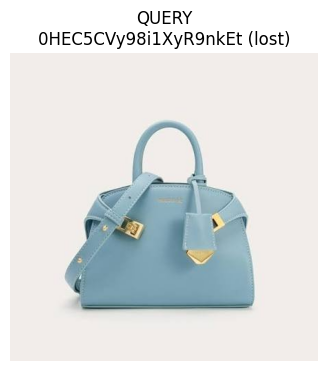

In [26]:
if len(meta) > 0:
    plt.figure(figsize=(4, 4))
    show_image_from_url(
        query_meta["imageUrl"],
        title=f"QUERY\n{query_meta['docId']} ({query_meta['collection']})"
    )
    plt.show()

# Show Top-K Images

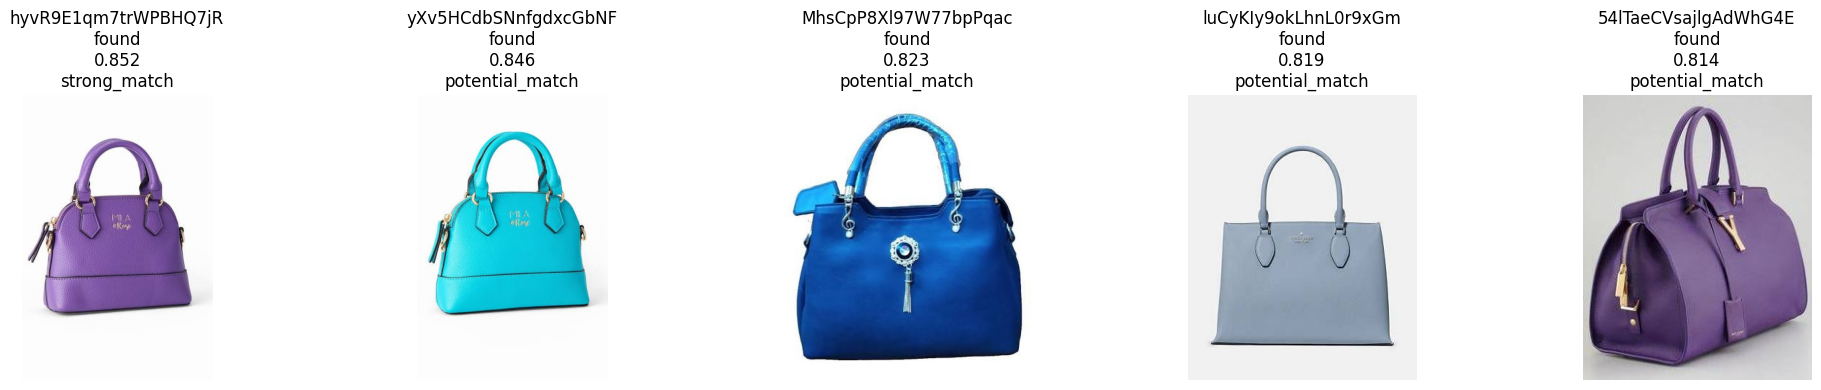

In [27]:
if len(meta) > 0 and len(results) > 0:
    fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))

    if len(results) == 1:
        axes = [axes]

    for ax, r in zip(axes, results):
        response = requests.get(r["imageUrl"], timeout=REQUEST_TIMEOUT)
        img = Image.open(io.BytesIO(response.content)).convert("RGB")
        ax.imshow(img)
        ax.set_title(
            f"{r['docId']}\n{r['collection']}\n{r['similarity']:.3f}\n{r['match_label']}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#### Save Preprocess Config

In [28]:
with open(os.path.join(ARTIFACT_DIR, "preprocess_config.json"), "w", encoding="utf-8") as f:
    json.dump(PREPROCESS_CONFIG, f, ensure_ascii=False, indent=2)

print("Saved preprocess_config.json")

Saved preprocess_config.json


#### Save Main Artifacts

In [29]:
# 1) embeddings
np.save(os.path.join(ARTIFACT_DIR, "embeddings.npy"), embeddings)

# 2) meta
with open(os.path.join(ARTIFACT_DIR, "meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

# 3) index info
with open(os.path.join(ARTIFACT_DIR, "index_info.json"), "w", encoding="utf-8") as f:
    json.dump(index_info, f, ensure_ascii=False, indent=2)

# 4) failed downloads
with open(os.path.join(ARTIFACT_DIR, "failed_downloads.json"), "w", encoding="utf-8") as f:
    json.dump(failed_downloads, f, ensure_ascii=False, indent=2)

# 5) non-indexable items
with open(os.path.join(ARTIFACT_DIR, "non_indexable_items.json"), "w", encoding="utf-8") as f:
    json.dump(non_indexable_items, f, ensure_ascii=False, indent=2)

# 6) download report
with open(os.path.join(ARTIFACT_DIR, "download_report.json"), "w", encoding="utf-8") as f:
    json.dump(download_report, f, ensure_ascii=False, indent=2)

# 7) runtime metrics
with open(os.path.join(ARTIFACT_DIR, "runtime_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(runtime_metrics, f, ensure_ascii=False, indent=2)

# 8) cleaning report
with open(os.path.join(ARTIFACT_DIR, "cleaning_report.json"), "w", encoding="utf-8") as f:
    json.dump(cleaning_report, f, ensure_ascii=False, indent=2)

print("All artifacts saved ")

All artifacts saved 


#### Verify Exported Files

In [30]:
expected_files = [
    "embeddings.npy",
    "meta.json",
    "index_info.json",
    "failed_downloads.json",
    "non_indexable_items.json",
    "download_report.json",
    "runtime_metrics.json",
    "cleaning_report.json",
    "preprocess_config.json"
]

for fname in expected_files:
    path = os.path.join(ARTIFACT_DIR, fname)
    print(f"{fname}: {os.path.exists(path)}")

embeddings.npy: True
meta.json: True
index_info.json: True
failed_downloads.json: True
non_indexable_items.json: True
download_report.json: True
runtime_metrics.json: True
cleaning_report.json: True
preprocess_config.json: True


## Final Summary

In [31]:
final_summary = {
    "indexed_items": len(meta),
    "failed_downloads": len(failed_downloads),
    "non_indexable_items": len(non_indexable_items),
    "embedding_shape": tuple(embeddings.shape),
    "index_id": index_id,
    "index_version": index_version
}

final_summary

{'indexed_items': 588,
 'failed_downloads': 0,
 'non_indexable_items': 0,
 'embedding_shape': (588, 576),
 'index_id': '5dbb2025-5917-4c5a-b7e2-015e24d79577',
 'index_version': '20260405_065345'}

In [32]:
# from google.colab import files
# import shutil

# shutil.make_archive("wadiah_artifacts", "zip", "artifacts")
# files.download("wadiah_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***un-comment if you want the zip ^^^***

In [35]:
# double check, they MUST be equal
print(len(embeddings), len(meta))

588 588
